In [328]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [329]:
df = pd.read_csv("loan_approval_data.csv")

In [330]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [331]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

# **Handling Missing Values**

In [332]:
categorical_cols = df.select_dtypes(include = ["object"]).columns
numerical_cols = df.select_dtypes(include = ["float64"]).columns

In [333]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy = "mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

cat_imp = SimpleImputer(strategy = "most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])


# **EDA - Exploratory Data Analysis**

Text(0.5, 1.0, 'Is Loan Approved or Not ?')

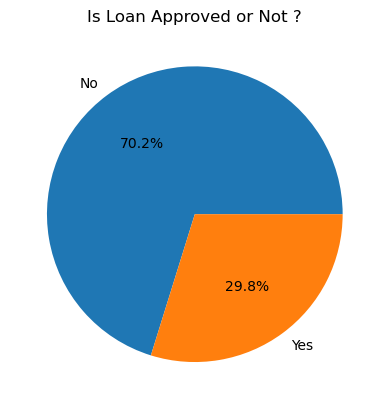

In [334]:
class_count = df["Loan_Approved"].value_counts()
plt.pie(class_count, labels = ["No", "Yes"], autopct = "%1.1f%%")
plt.title("Is Loan Approved or Not ?")


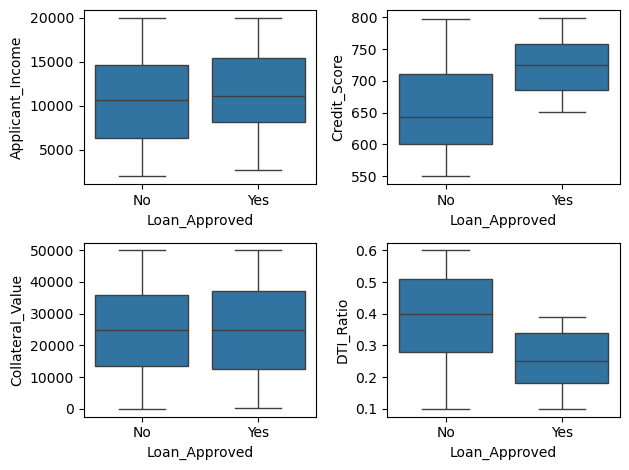

In [335]:
# outlier Detection

fig, axes = plt.subplots(2, 2)

sns.boxplot(ax = axes[0, 0], data = df, x = "Loan_Approved", y = "Applicant_Income")
sns.boxplot(ax = axes[0, 1], data = df, x = "Loan_Approved", y = "Credit_Score")
sns.boxplot(ax = axes[1, 0], data = df, x = "Loan_Approved", y = "Collateral_Value")
sns.boxplot(ax = axes[1, 1], data = df, x = "Loan_Approved", y = "DTI_Ratio")

plt.tight_layout()

<Axes: xlabel='Applicant_Income', ylabel='Loan_Amount'>

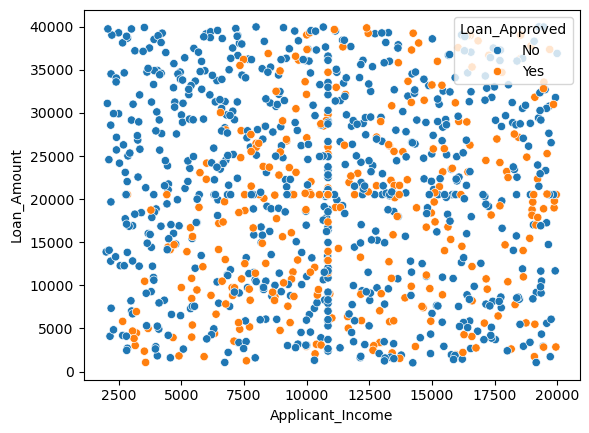

In [336]:
sns.scatterplot(
    x="Applicant_Income",
    y="Loan_Amount",
    hue="Loan_Approved",
    data=df
)

# **Encoding**

In [338]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])


In [339]:
from sklearn.preprocessing import OneHotEncoder

cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Gender", "Employer_Category", "Property_Area"]

ohe = OneHotEncoder(drop = "first", sparse_output = False, handle_unknown = "ignore")

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded, columns = ohe.get_feature_names_out(cols))

df = pd.concat([df.drop(columns = cols),  encoded_df], axis = 1)

df = df.drop("Applicant_ID", axis = 1)

In [ ]:
df.head()

# **Co Relation Heat Map**

<Figure size 2400x2000 with 0 Axes>

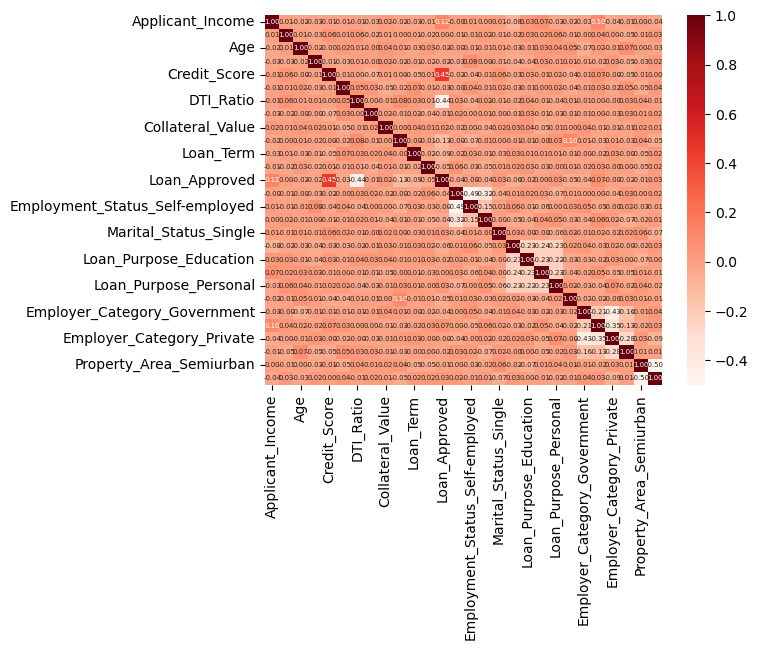

<Figure size 2400x2000 with 0 Axes>

In [340]:
# Co Relation HeatMap

numerical_cols = df.select_dtypes(include = ["number"])
corr_matrix = numerical_cols.corr()

sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    cmap = "Reds",
    annot_kws={"size": 5}
)

plt.figure(figsize=(24, 20))


#  **Train-Test-Split**

In [344]:
X = df.drop("Loan_Approved", axis = 1)
y = df["Loan_Approved"]

In [345]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# **Scaling Numeric Features**

In [346]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler();

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# **Model Training**

In [347]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

y_pred = nb_model.predict(X_test_scaled)

# **Model Evaluation**

In [341]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix, f1_score, accuracy_score

print("Naive Bayes Model")
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("CM: ", confusion_matrix(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))

Naive Bayes Model
Precision:  0.8035714285714286
Recall:  0.7377049180327869
F1 Score:  0.7692307692307693
CM:  [[128  11]
 [ 16  45]]
Accuracy:  0.865
